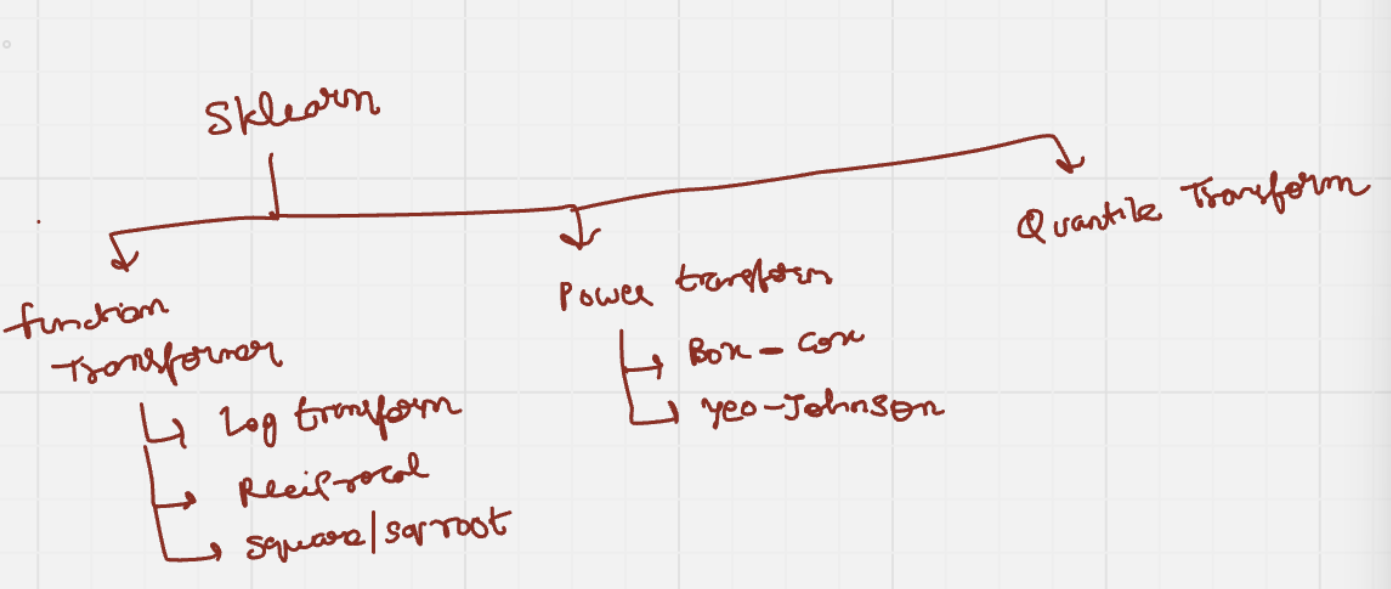

A practical ranking is:

Yeo-Johnson: most flexible overall

Box-Cox: very strong when data is strictly positive

Log transform: simple and very effective for right-skewed positive data

Square-root transform: milder than log, sometimes useful for moderate right skew

Reciprocal transform: very aggressive, but can distort data heavily

Square transform: usually for some left-skewed cases, but not generally the first choice

# Power Transformer

This notebook shows two scikit-learn power transformations used to reduce skewness and make data closer to normal:

- `Box-Cox`
- `Yeo-Johnson`

We will compare each method using:

- histograms
- Q-Q plots
- the Shapiro-Wilk normality test

`Box-Cox` works only on strictly positive data.
`Yeo-Johnson` can work on positive, zero, and negative values.

In [4]:
# Import libraries and generate sample datasets
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer

np.random.seed(42)

# Strictly positive right-skewed data for Box-Cox
boxcox_input = np.random.exponential(scale=10, size=500) + 1

# Clearly non-normal skewed data with some negative values for Yeo-Johnson
yeojohnson_input = np.random.chisquare(df=2, size=500) - 2

print('Box-Cox input sample:', boxcox_input[:5])
print('Yeo-Johnson input sample:', yeojohnson_input[:5])

Box-Cox input sample: [ 5.6926809  31.10121431 14.16745694 10.12942554  2.6962487 ]
Yeo-Johnson input sample: [ 0.39572776 -0.46384313 -1.2592414   1.36181433  0.30865917]


## Box-Cox Transformation

`Box-Cox` is useful for strongly right-skewed positive data.

It tries to find a power transformation that makes the distribution more symmetric and closer to normal.

Because Box-Cox requires all values to be strictly positive, we use a positive exponential sample below.

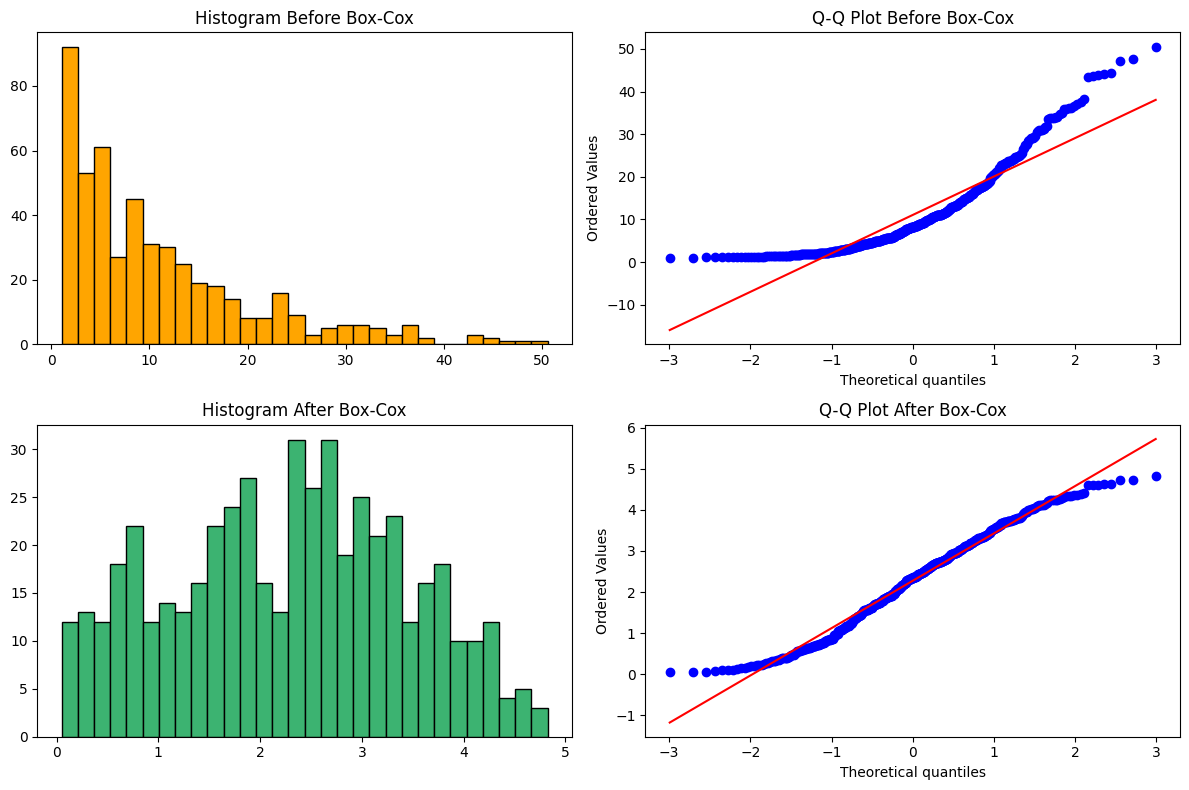

Shapiro-Wilk p-value before Box-Cox: 2.43780e-21
Shapiro-Wilk p-value after Box-Cox: 2.41623e-06
Skewness before Box-Cox: 1.4409
Skewness after Box-Cox: -0.02802
Box-Cox reduces skewness and makes the data closer to normal.
After Box-Cox, the data is still not fully normal.


In [2]:
# Apply Box-Cox and compare before and after
boxcox_transformer = PowerTransformer(method='box-cox', standardize=False)
boxcox_output = boxcox_transformer.fit_transform(boxcox_input.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(boxcox_input, bins=30, color='orange', edgecolor='black')
axes[0, 0].set_title('Histogram Before Box-Cox')

stats.probplot(boxcox_input, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot Before Box-Cox')

axes[1, 0].hist(boxcox_output, bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Histogram After Box-Cox')

stats.probplot(boxcox_output, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot After Box-Cox')

plt.tight_layout()
plt.show()

boxcox_before_p = stats.shapiro(boxcox_input).pvalue
boxcox_after_p = stats.shapiro(boxcox_output).pvalue
boxcox_before_skew = stats.skew(boxcox_input)
boxcox_after_skew = stats.skew(boxcox_output)

print(f'Shapiro-Wilk p-value before Box-Cox: {boxcox_before_p:.5e}')
print(f'Shapiro-Wilk p-value after Box-Cox: {boxcox_after_p:.5e}')
print('Skewness before Box-Cox:', round(boxcox_before_skew, 5))
print('Skewness after Box-Cox:', round(boxcox_after_skew, 5))

if abs(boxcox_after_skew) < abs(boxcox_before_skew):
    print('Box-Cox reduces skewness and makes the data closer to normal.')
else:
    print('Box-Cox does not improve the skewness in this example.')

if boxcox_after_p > 0.05:
    print('After Box-Cox, the data looks approximately normal.')
else:
    print('After Box-Cox, the data is still not fully normal.')

## Yeo-Johnson Transformation

`Yeo-Johnson` is similar to Box-Cox, but it also works when the data contains zero or negative values.

That makes it more flexible for real-world features that are not strictly positive.

Below, we apply it to a sample that contains both negative and positive values.

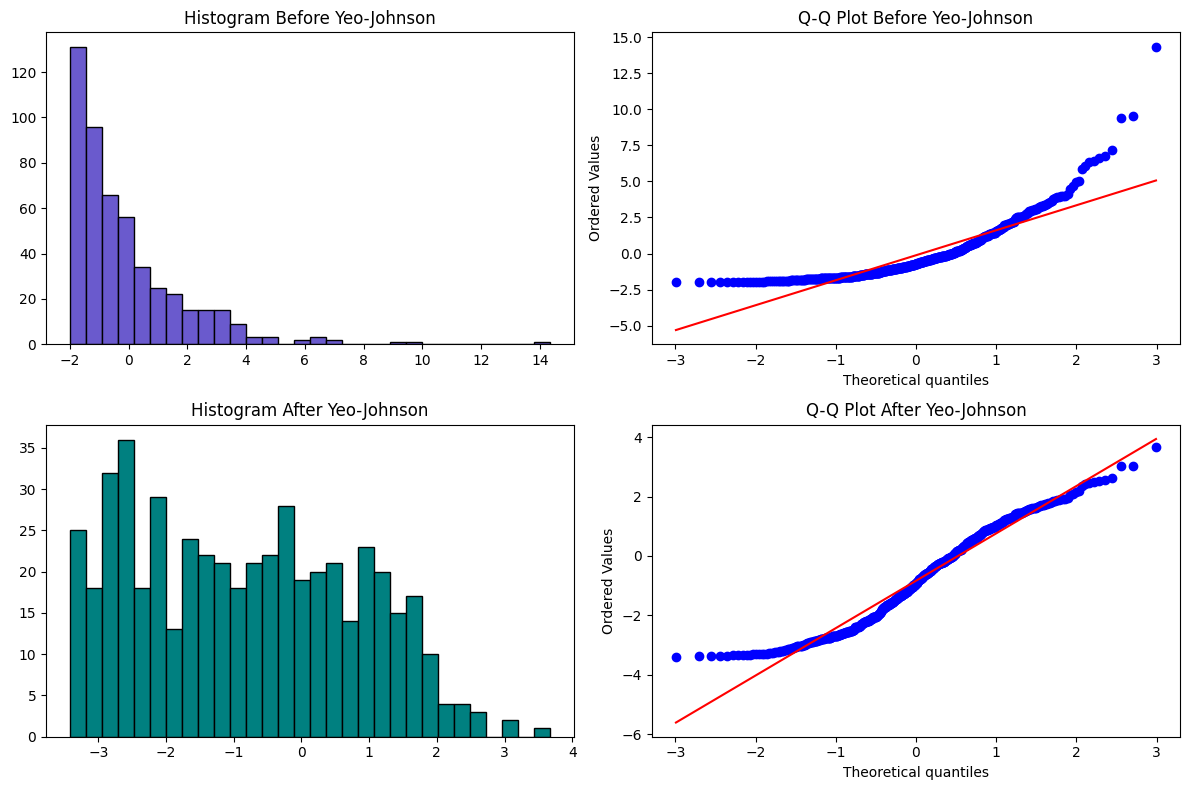

Shapiro-Wilk p-value before Yeo-Johnson: 8.43354e-25
Shapiro-Wilk p-value after Yeo-Johnson: 3.25418e-10
Skewness before Yeo-Johnson: 2.29862
Skewness after Yeo-Johnson: 0.22578
Yeo-Johnson reduces skewness and makes the data closer to normal.
After Yeo-Johnson, the data is still not fully normal.


In [5]:
# Apply Yeo-Johnson and compare before and after
yeojohnson_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
yeojohnson_output = yeojohnson_transformer.fit_transform(yeojohnson_input.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(yeojohnson_input, bins=30, color='slateblue', edgecolor='black')
axes[0, 0].set_title('Histogram Before Yeo-Johnson')

stats.probplot(yeojohnson_input, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot Before Yeo-Johnson')

axes[1, 0].hist(yeojohnson_output, bins=30, color='teal', edgecolor='black')
axes[1, 0].set_title('Histogram After Yeo-Johnson')

stats.probplot(yeojohnson_output, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot After Yeo-Johnson')

plt.tight_layout()
plt.show()

yeojohnson_before_p = stats.shapiro(yeojohnson_input).pvalue
yeojohnson_after_p = stats.shapiro(yeojohnson_output).pvalue
yeojohnson_before_skew = stats.skew(yeojohnson_input)
yeojohnson_after_skew = stats.skew(yeojohnson_output)

print(f'Shapiro-Wilk p-value before Yeo-Johnson: {yeojohnson_before_p:.5e}')
print(f'Shapiro-Wilk p-value after Yeo-Johnson: {yeojohnson_after_p:.5e}')
print('Skewness before Yeo-Johnson:', round(yeojohnson_before_skew, 5))
print('Skewness after Yeo-Johnson:', round(yeojohnson_after_skew, 5))

if abs(yeojohnson_after_skew) < abs(yeojohnson_before_skew):
    print('Yeo-Johnson reduces skewness and makes the data closer to normal.')
else:
    print('Yeo-Johnson does not improve the skewness in this example.')

if yeojohnson_after_p > 0.05:
    print('After Yeo-Johnson, the data looks approximately normal.')
else:
    print('After Yeo-Johnson, the data is still not fully normal.')